In [2]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
fig, ax = plt.subplots(3,1, figsize = (8,7))

df = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(['Data Analyst', 'Data Scientist', 'Data Engineer']))]
df = df.explode(column = 'job_skills')
df = df.dropna(subset = 'job_skills')
pivot = df.pivot_table(index = 'job_skills', columns = 'job_title_short', aggfunc = 'size')

pivot_analyst = pivot['Data Analyst'].sort_values(ascending = False).head(10)
pivot_eng = pivot['Data Engineer'].sort_values(ascending = False).head(10)
pivot_sci = pivot['Data Scientist'].sort_values(ascendin g = False).head(10)
fig.suptitle('Count Of Top Skills In Job Postings')

sns.barplot(x = pivot_analyst.values,
             y = pivot_analyst.index,
             ax= ax[0],
             hue = pivot_analyst.values,
             palette = 'dark:blue_r',
             legend = False,)

ax[0].set_title('Data Analyst')
ax[0].set_xlabel('Count')
ax[0].set_ylabel('Skill')
ax[0].set_xlim(0, 42000)



sns.barplot(x = pivot_eng.values,
             y = pivot_eng.index,ax= ax[1],
             hue = pivot_eng.values,
             palette = 'dark:pink_r',
             legend = False)

ax[1].set_title('Data Engineer')
ax[1].set_xlabel('Count')
ax[1].set_ylabel('Skill')
ax[1].set_xlim(0, 42000)

sns.barplot(x = pivot_sci.values,
             y = pivot_sci.index,
             ax= ax[2],
             hue = pivot_sci.values,
             palette = 'dark:green_r',
             legend = False)

ax[2].set_title('Data Scientist')
ax[2].set_xlabel('Count')
ax[2].set_ylabel('Skill')
ax[2].set_xlim(0, 42000)


fig.tight_layout()
plt.show


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2978694632.py, line 10)

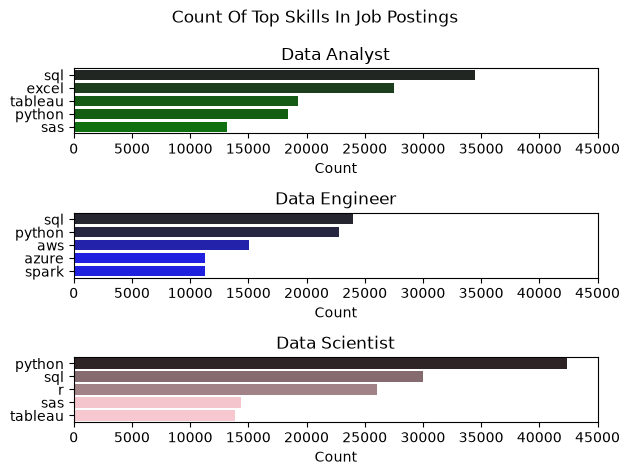

In [ ]:
fig, ax = plt.subplots(3,1)

df = df[df['job_country'] == 'United States']
df = df.explode(column = 'job_skills')

grouped = df.groupby(['job_title_short', 'job_skills']).size()
grouped = grouped.to_frame(name='skill_count').reset_index()
grouped = grouped.sort_values(by = 'skill_count', ascending = False )

job_title = grouped['job_title_short'].unique().tolist()
job_title = sorted(job_title[:3])

color = ['dark:green_r', 'dark:blue_r', 'dark:pink_r']
for i, job_title in enumerate(job_title):
        plot = grouped[grouped['job_title_short'] == job_title].sort_values(ascending = False, by = 'skill_count').head(5 )
        sns.barplot(data = plot , x = 'skill_count', y = 'job_skills', ax = ax[i], hue = 'skill_count', palette = color[i], legend = False)
        ax[i].set_title(job_title)
        ax[i].set_xlabel('Count')
        ax[i].set_ylabel('')
        ax[i].set_xlim(0,45000)
        ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'{}')

fig.suptitle('Count Of Top Skills In Job Postings')
plt.tight_layout()
plt.show()


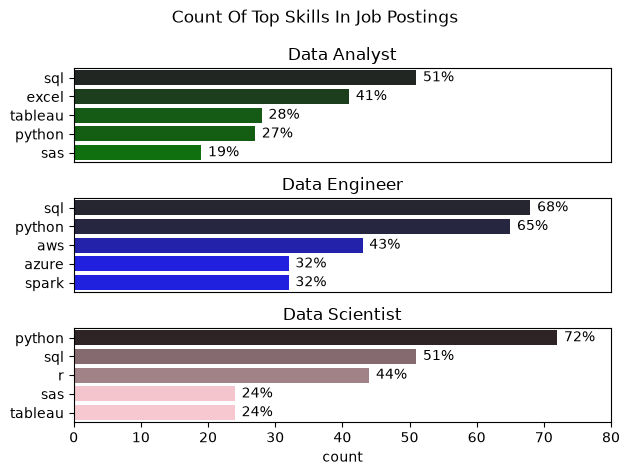

In [5]:
fig, ax = plt.subplots(3,1)

df = df[df['job_country'] == 'United States']
exploded = df.explode(column = 'job_skills')


grouped = exploded.groupby(['job_title_short', 'job_skills']).size()
grouped = grouped.to_frame(name='skill_count').reset_index()
grouped = grouped.sort_values(by = 'skill_count', ascending = False )


job_titles = grouped['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

count = df['job_title_short'].value_counts().reset_index(name = 'jobs_total')
skills_perc = pd.merge(grouped, count,  how = 'left', on = 'job_title_short')#Merge grouped and count using job_title_short, but keep all the rows from grouped.
skills_perc['percent'] = round(skills_perc['skill_count']/skills_perc['jobs_total'],2)*100

color = ['dark:green_r', 'dark:blue_r', 'dark:pink_r']
for i, job_title in enumerate(job_titles):
        plot = skills_perc[skills_perc['job_title_short'] == job_title].sort_values(ascending = False, by = 'skill_count').head(5 )
        sns.barplot(data = plot , x = 'percent', y = 'job_skills', ax = ax[i], hue = 'skill_count', palette = color[i], legend = False)
        ax[i].set_title(job_title)
        
        ax[i].set_ylabel('')
        ax[i].set_xlim(0,80)

        for n, v in enumerate(plot['percent']):
                ax[i].text(v + 1,n,f'{v:.0f}%', va ='center')

        if i != len(job_titles) - 1:
                ax[i].set_xticks([])
                ax[i].set_xlabel('')
        ax[2].set_xlabel('count')
       


fig.suptitle('Count Of Top Skills In Job Postings')
plt.tight_layout()
plt.show()
